In [23]:
# from dotenv import load_dotenv
# load_dotenv()

In [24]:
import json
import textwrap
import pandas as pd
from ipywidgets import widgets
from IPython.display import display
from ipywidgets import HBox
import matplotlib.pyplot as plt
from tabulate import tabulate

In [25]:
# Load the wandb table data
def load_wandb_data(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data['data'], columns=data['columns'])

In [26]:
def fixedwidth(text):
    """Wrap text to fixed width"""
    return "\n".join(textwrap.wrap(str(text), width=160, replace_whitespace=False))

def format_row(row):
    """Format a single row for display as a table"""
    data = [
        ["Step", row['Step']],
        ["Reward", f"{row['Reward']:.2f}"],
        ["Input", row['Input']],
        ["Prompt", fixedwidth(row['Prompt'])], 
        ["Completion", fixedwidth(row['Completion'])],
    ]
    return tabulate(data, tablefmt='grid')

def present_row(row):
    """Display a formatted row as table"""
    print(format_row(row))

In [27]:
def create_browse_app(df):
    """Create an interactive widget to browse through the data"""
    def browse_data(i=0):
        row = df.iloc[i]
        present_row(row)

    index = widgets.IntText(value=0, description='Index:')
    left_button = widgets.Button(description='Previous')
    right_button = widgets.Button(description='Next')

    def on_left_button_clicked(b):
        if index.value > 0:
            index.value -= 1

    def on_right_button_clicked(b):
        if index.value < len(df) - 1:
            index.value += 1

    left_button.on_click(on_left_button_clicked)
    right_button.on_click(on_right_button_clicked)

    ui = HBox([left_button, index, right_button])
    out = widgets.interactive_output(browse_data, {'i': index})

    display(ui, out)

In [28]:
def preprocess_df(df):
    df['Step'] = df['Step'].astype(int)
    df['Reward'] = df['Reward'].astype(float)
    df['Input'] = df['Input'].astype(str)
    df['Prompt'] = df['Prompt'].astype(str)
    df['Completion'] = df['Completion'].astype(str)
    df['Prompt'] = df['Prompt'].map(lambda x: x.rsplit('**user**:', 1)[-1])
    df.sort_values(by="Step", ascending=False, inplace=True)
    return df

In [29]:
# Load and display your data
from pathlib import Path

# read all json files in the directory using pathlib
run_name = 'run-20250413_235627-w1ck91gt'
directory = f"../wandb/{run_name}/files/media/table"
files = list(Path(directory).glob("interactions_*.json"))

# load all json files
df = pd.concat([load_wandb_data(f) for f in files])
df = preprocess_df(df)
print(len(df))

159360


In [30]:
df.loc[df['Completion'].str.contains("timed out")]

,Step,Input,Prompt,Completion,Reward
13,1622,id: 2hop__159029_26501\n\nanswer: mid-7th to e...,In what time period did the Muslim conquest o...,"**assistant**: <think>\nTo find the answer, I ...",1.90
25,1606,id: 4hop1__32903_103178_69867_36839\n\nanswer:...,How did the Japanese win the country into whi...,**assistant**: <think> We need to identify the...,2.14
28,1588,id: 4hop2__205028_81195_91861_124556\n\nanswer...,Who fathered the leader of the first expediti...,"**assistant**: <think>\nTo find the answer, we...",4.32
36,1542,id: 2hop__532485_36414\n\nanswer: 46%\n\nanswe...,What percent of the people in the country con...,"**assistant**: <think> To find the answer, I n...",2.42
25,1518,id: 2hop__847354_23140\n\nanswer: 11 percent\n...,What's debt-to-GDP ratio of the country that ...,**assistant**: <think> I need to identify the ...,4.38
...,...,...,...,...,...
12,78,id: 4hop1__46253_22372_375457_49140\n\nanswer:...,What was the 2018 population of the host coun...,**assistant**: <think>\nTo solve this question...,3.99
12,76,id: 2hop__60060_15928\n\nanswer: the Arian pos...,Whose is the position that the person symboli...,"**assistant**: <think>\nTo find the answer, I ...",2.28
7,58,id: 2hop__818191_86395\n\nanswer: 1 August 197...,When did the country where El Paso is located...,"**assistant**: <think>\nTo find the answer, we...",1.84
3,32,id: 2hop__13957_14056\n\nanswer: 1207\n\nanswe...,When did the sole surviving son create a new ...,"**assistant**: <think>\nTo find the answer, I ...",1.94


In [31]:
# Create the interactive browser
create_browse_app(df)

Output()

In [32]:
retrieval_attempt_mask = df['Completion'].str.contains("timed out")
df.loc[retrieval_attempt_mask]

,Step,Input,Prompt,Completion,Reward
13,1622,id: 2hop__159029_26501\n\nanswer: mid-7th to e...,In what time period did the Muslim conquest o...,"**assistant**: <think>\nTo find the answer, I ...",1.90
25,1606,id: 4hop1__32903_103178_69867_36839\n\nanswer:...,How did the Japanese win the country into whi...,**assistant**: <think> We need to identify the...,2.14
28,1588,id: 4hop2__205028_81195_91861_124556\n\nanswer...,Who fathered the leader of the first expediti...,"**assistant**: <think>\nTo find the answer, we...",4.32
36,1542,id: 2hop__532485_36414\n\nanswer: 46%\n\nanswe...,What percent of the people in the country con...,"**assistant**: <think> To find the answer, I n...",2.42
25,1518,id: 2hop__847354_23140\n\nanswer: 11 percent\n...,What's debt-to-GDP ratio of the country that ...,**assistant**: <think> I need to identify the ...,4.38
...,...,...,...,...,...
12,78,id: 4hop1__46253_22372_375457_49140\n\nanswer:...,What was the 2018 population of the host coun...,**assistant**: <think>\nTo solve this question...,3.99
12,76,id: 2hop__60060_15928\n\nanswer: the Arian pos...,Whose is the position that the person symboli...,"**assistant**: <think>\nTo find the answer, I ...",2.28
7,58,id: 2hop__818191_86395\n\nanswer: 1 August 197...,When did the country where El Paso is located...,"**assistant**: <think>\nTo find the answer, we...",1.84
3,32,id: 2hop__13957_14056\n\nanswer: 1207\n\nanswe...,When did the sole surviving son create a new ...,"**assistant**: <think>\nTo find the answer, I ...",1.94


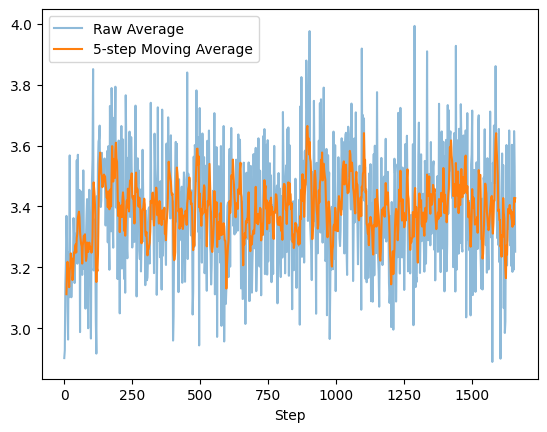

In [33]:
# plot average reward by step
# Plot raw average and moving average
means = df.groupby('Step')['Reward'].mean()
means.plot(alpha=0.5, label='Raw Average')
means.rolling(window=5).mean().plot(label='5-step Moving Average')
plt.legend()

In [34]:
from ast import literal_eval

def extract_titles(completion):
    # Extract titles from the completion
    for line in completion.splitlines():
        if line.startswith('#'):
            yield line.split('#')[1].strip()

# Apply the function to the 'Completion' column
df['Retrieved Titles'] = df['Completion'].apply(lambda x: list(extract_titles(x)))

df['Supporting Titles'] = df['Input'].map(lambda x: x.split('supporting_titles:', 1)[-1]).map(literal_eval)


<Axes: >

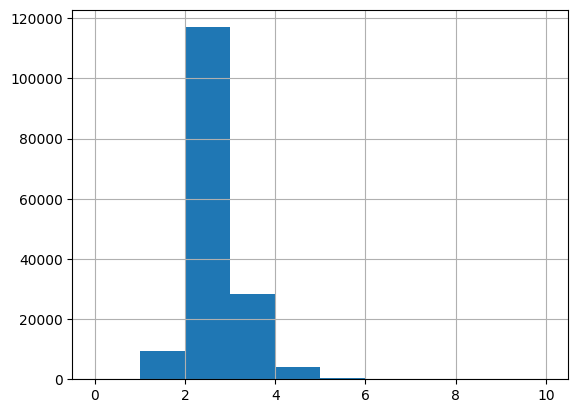

In [35]:
df['Retrieved Titles'].map(len).hist()

In [36]:
df['Successfully Retrieved Titles'] = df.apply(lambda row: set(row['Retrieved Titles']).intersection(row['Supporting Titles']), axis=1)
df['retrieval.recall'] = df['Successfully Retrieved Titles'].map(len) / df['Supporting Titles'].map(len)
df['retrieval.precision'] = df['Successfully Retrieved Titles'].map(len) / df['Retrieved Titles'].map(len)

In [37]:
retrieval_attempt_mask = df['Retrieved Titles'].map(len) > 0
len(df[retrieval_attempt_mask]) / len(df)

0.9989395080321285

In [38]:
df.loc[retrieval_attempt_mask, 'retrieval.recall'].describe()

count    159191.000000
mean          0.812185
std           0.266522
min           0.000000
25%           0.500000
50%           1.000000
75%           1.000000
max           1.000000
Name: retrieval.recall, dtype: float64

In [39]:
df.loc[retrieval_attempt_mask, 'retrieval.precision'].describe()

count    159191.000000
mean          0.865695
std           0.250960
min           0.000000
25%           0.750000
50%           1.000000
75%           1.000000
max           1.000000
Name: retrieval.precision, dtype: float64

In [40]:
error_mask = df['Completion'].str.contains("Error")
len(df.loc[error_mask]) / len(df)


0.0347640562248996

<Axes: >

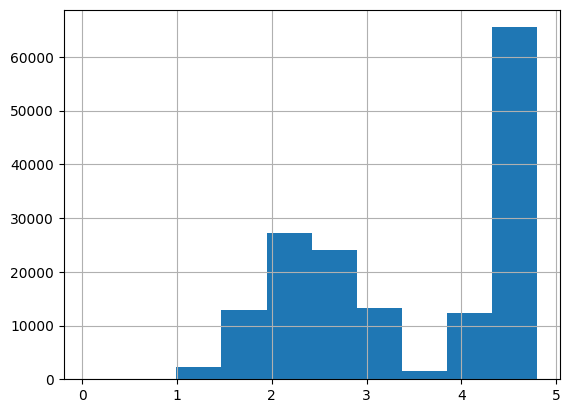

In [41]:
df['Reward'].hist()

In [42]:
# plot reward distribution characteristics per prompt
prompt_reward_stats = df.groupby('Prompt')['Reward'].describe()

<Axes: xlabel='std', ylabel='mean'>

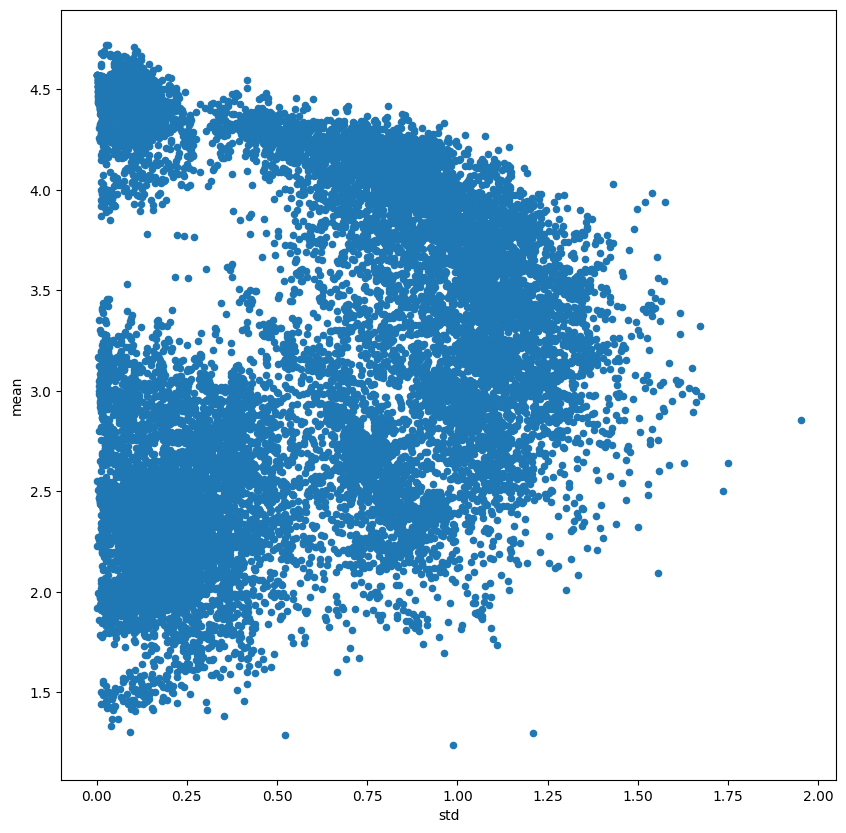

In [43]:
prompt_reward_stats.plot.scatter(x='std', y='mean', figsize=(10, 10))